# Demo: Imputación de datos faltantes vía proceso Ornstein-Uhlenbeck

Este notebook genera una serie sintética de un proceso OU, le remueve un segmento
de datos, y usa el mecanismo de imputación (puentes OU + re-estimación MLE) para
rellenarlo. No depende de datos institucionales reales.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from ou_estimation import euler_maruyama_ou, mu_sigma_mle
from em_imputation import euler_maruyama_bridge_ou, p_val_ou, separate_by_continuity

np.random.seed(1)
%matplotlib inline

/usr/local/lib/python3.10/dist-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 1. Generar la serie sintética completa

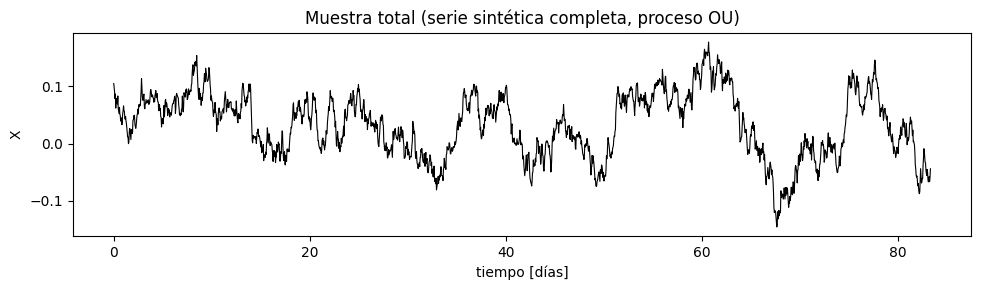

In [2]:
TRUE_MU, TRUE_SIGMA = 0.3, 0.05
N_POINTS, DT = 2000, 1 / 24  # dt = 1 hora, en unidades de dias

X_true = euler_maruyama_ou(N_POINTS, DT, TRUE_MU, TRUE_SIGMA)
t = np.arange(N_POINTS) * DT

plt.figure(figsize=(10, 3))
plt.plot(t, X_true, color='black', linewidth=0.8)
plt.title('Muestra total (serie sintética completa, proceso OU)')
plt.xlabel('tiempo [días]')
plt.ylabel('X')
plt.tight_layout()
plt.show()

## 2. Insertar un hueco de datos faltantes

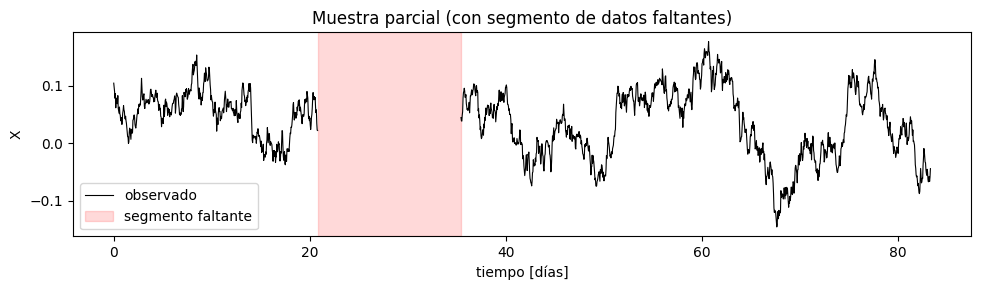

In [3]:
X_observed = X_true.copy()
gap_start, gap_end = 500, 850
X_observed[gap_start:gap_end] = np.nan



plt.figure(figsize=(10, 3))
plt.plot(t, X_observed, color='black', linewidth=0.8, label='observado')
plt.axvspan(t[gap_start], t[gap_end], color='red', alpha=0.15, label='segmento faltante')
plt.title('Muestra parcial (con segmento de datos faltantes)')
plt.xlabel('tiempo [días]')
plt.ylabel('X')
plt.legend()
plt.tight_layout()
plt.show()

## 3. Imputación vía EM

Se alterna entre (E) rellenar el hueco con un puente del proceso OU usando los
parámetros actuales, y (M) re-estimar `(mu, sigma)` con la serie ya rellenada.

In [4]:
index_nans = np.where(np.isnan(X_observed))[0]
sub_index_nans = separate_by_continuity(index_nans)

mu, sigma = 1.0, 1.0  # valores iniciales, lejos de los verdaderos a propósito
X_filled = X_observed.copy()

mu_history, sigma_history = [mu], [sigma]

for step in range(15):
    for idx in sub_index_nans:
        X0, Xf = X_filled[idx[0] - 1], X_filled[idx[-1] + 1]
        bridge = euler_maruyama_bridge_ou(X0, Xf, idx.shape[0] + 2, DT, mu, sigma)
        X_filled[idx] = bridge[1:-1]
    mu, sigma = mu_sigma_mle(X_filled, DT)
    mu_history.append(mu)
    sigma_history.append(sigma)

mu_ref, sigma_ref = mu_sigma_mle(X_true, DT)

print(f'Referencia (datos completos):  mu={mu_ref:.4f}, sigma={sigma_ref:.4f}')
print(f'Valores verdaderos simulados:  mu={TRUE_MU:.4f}, sigma={TRUE_SIGMA:.4f}')
print(f'Estimacion final tras EM:      mu={mu:.4f}, sigma={sigma:.4f}')

Referencia (datos completos):  mu=0.3221, sigma=0.0506
Valores verdaderos simulados:  mu=0.3000, sigma=0.0500
Estimacion final tras EM:      mu=0.3101, sigma=0.0508


## 4. Convergencia de las estimaciones a través de las iteraciones

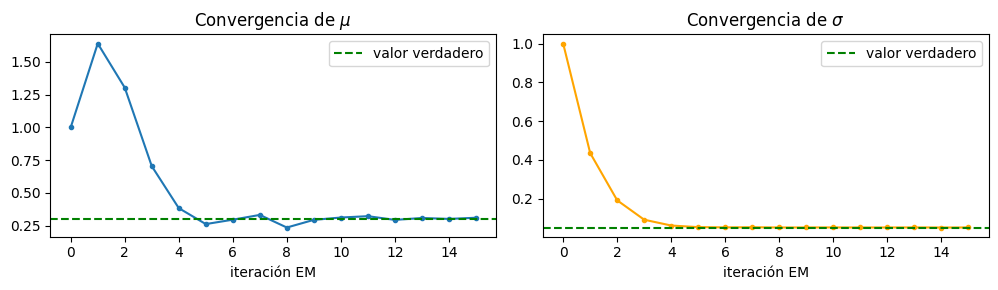

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].plot(mu_history, marker='o', markersize=3)
ax[0].axhline(TRUE_MU, color='green', linestyle='--', label='valor verdadero')
ax[0].set_title(r'Convergencia de $\mu$')
ax[0].set_xlabel('iteración EM')
ax[0].legend()

ax[1].plot(sigma_history, marker='o', markersize=3, color='orange')
ax[1].axhline(TRUE_SIGMA, color='green', linestyle='--', label='valor verdadero')
ax[1].set_title(r'Convergencia de $\sigma$')
ax[1].set_xlabel('iteración EM')
ax[1].legend()

plt.tight_layout()
plt.show()

## 5. Rellenado final vs. serie original

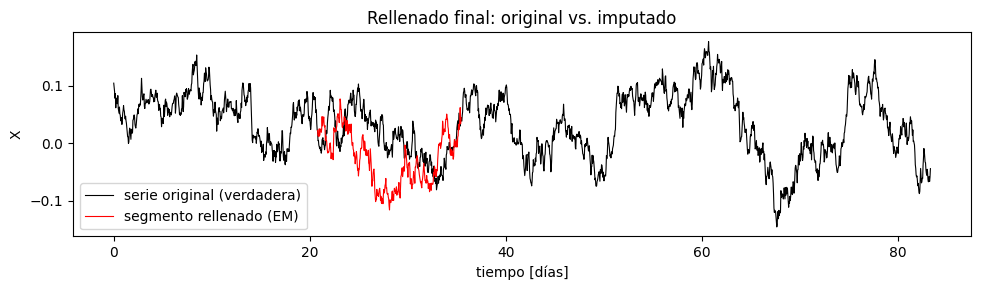

In [9]:
plt.figure(figsize=(10, 3))
plt.plot(t, X_true, color='black', linewidth=0.8, label='serie original (verdadera)')
plt.plot(t[gap_start-1:gap_end+1], X_filled[gap_start-1:gap_end+1], color='red', linewidth=0.8, label='segmento rellenado (EM)')
plt.title('Rellenado final: original vs. imputado')
plt.xlabel('tiempo [días]')
plt.ylabel('X')
plt.legend()
plt.tight_layout()
plt.show()

## 6. Bondad de ajuste de la serie rellenada

In [7]:
p_val, T = p_val_ou(X_filled, DT, mu, sigma)
print(f'p-valor: {p_val:.4f}  (T={T:.2f})')
print('Un p-valor alto sugiere que la serie rellenada es consistente con un proceso OU(mu, sigma).')

p-valor: 0.6482  (T=1974.38)
Un p-valor alto sugiere que la serie rellenada es consistente con un proceso OU(mu, sigma).
